In [1]:
import pandas as pd
import xarray as xr

path = '/storage/ice-shared/bmed6780/climate/na_cordex_monthly_2000_2025_conus.nc'
ds = xr.open_dataset(path)
ds

<xarray.Dataset> Size: 980MB
Dimensions:    (member_id: 16, time: 312, lat: 104, lon: 236)
Coordinates:
  * lat        (lat) float64 832B 24.12 24.38 24.62 24.88 ... 49.38 49.62 49.88
  * lon        (lon) float64 2kB -124.9 -124.6 -124.4 ... -66.62 -66.38 -66.12
  * member_id  (member_id) <U21 1kB 'MPI-ESM-MR.CRCM5-UQAM' ... 'MPI-ESM-LR.WRF'
  * time       (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2025-12-01
Data variables:
    tas        (member_id, time, lat, lon) float32 490MB ...
    hurs       (member_id, time, lat, lon) float32 490MB ...
Attributes:
    title:          NA-CORDEX Monthly CONUS (hist-rcp85, NAM-22i, raw)
    source:         NCAR NA-CORDEX on AWS S3
    history:        Daily data resampled to monthly means, subset to CONUS
    time_coverage:  2000-01 to 2025-12

In [4]:
import xarray as xr
import pandas as pd
import os

# --- Load dataset ---
path = '/storage/ice-shared/bmed6780/climate/na_cordex_monthly_2000_2025_conus.nc'
ds = xr.open_dataset(path)

# --- Define cities with coordinates ---
cities = {
    "Atlanta": (33.75, -84.39),
    "Los_Angeles": (34.05, -118.25),
    "Chicago": (41.88, -87.63),
    "San_Francisco": (37.77, -122.42),
    "New_York": (40.71, -74.01),
    "St_Louis": (38.63, -90.20)
}

# --- Output directory (change if needed) ---
output_dir = "/home/hice1/jblack74/scratch/BHI/NEW_Cordex"
os.makedirs(output_dir, exist_ok=True)

# --- Loop through cities ---
for city, (lat_city, lon_city) in cities.items():
    
    # Extract nearest grid point
    tas = ds['tas'].sel(lat=lat_city, lon=lon_city, method='nearest')
    hurs = ds['hurs'].sel(lat=lat_city, lon=lon_city, method='nearest')
    
    # Align time dimension
    tas, hurs = xr.align(tas, hurs)
    
    # Convert to 1D arrays
    tas_vals = tas.squeeze().values.flatten()
    hurs_vals = hurs.squeeze().values.flatten()
    times = pd.to_datetime(tas['time'].values)
    
    # Ensure equal lengths
    min_len = min(len(times), len(tas_vals), len(hurs_vals))
    
    df = pd.DataFrame({
        'time': times[:min_len],
        'tas': tas_vals[:min_len],
        'hurs': hurs_vals[:min_len],
    })
    
    # Save CSV
    filename = os.path.join(output_dir, f"{city}_climate_v1.csv")
    df.to_csv(filename, index=False)
    
    print(f"Saved {city} data to {filename}")

Saved Atlanta data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/Atlanta_climate_v1.csv
Saved Los_Angeles data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/Los_Angeles_climate_v1.csv
Saved Chicago data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/Chicago_climate_v1.csv
Saved San_Francisco data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/San_Francisco_climate_v1.csv
Saved New_York data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/New_York_climate_v1.csv
Saved St_Louis data to /home/hice1/jblack74/scratch/BHI/NEW_Cordex/St_Louis_climate_v1.csv


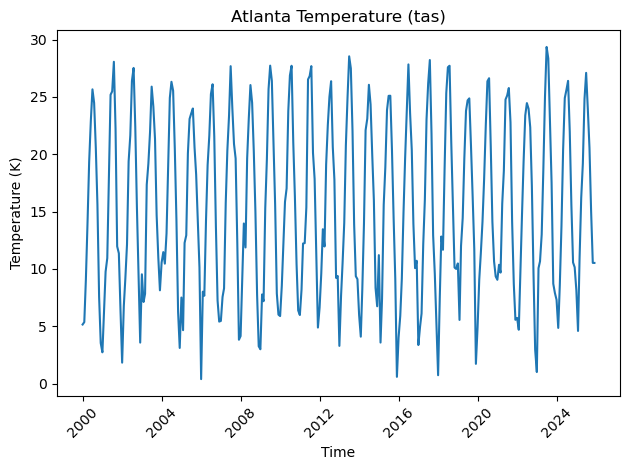

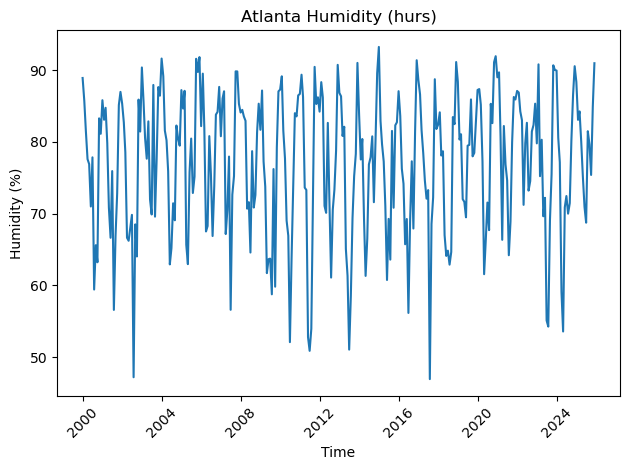

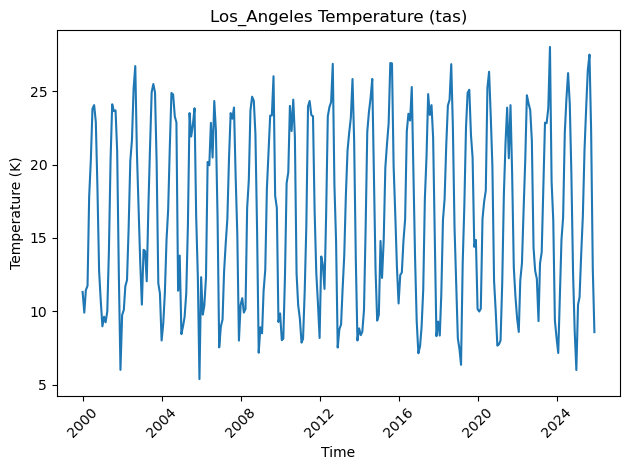

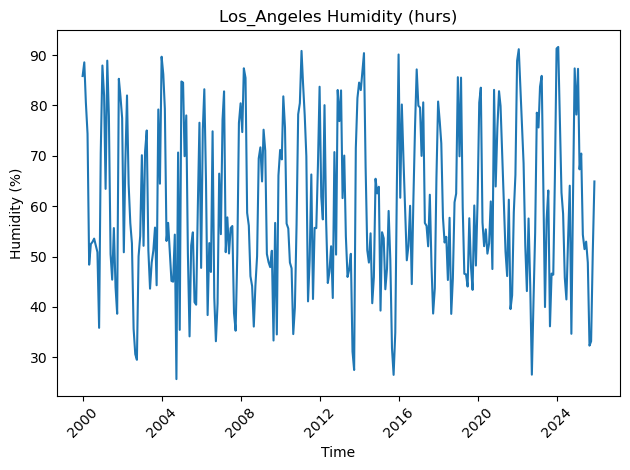

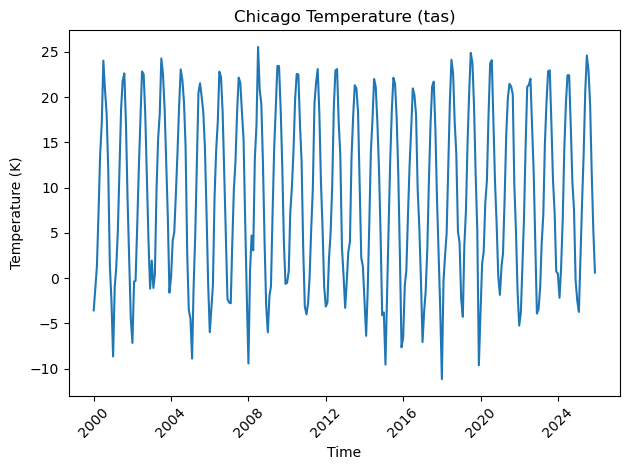

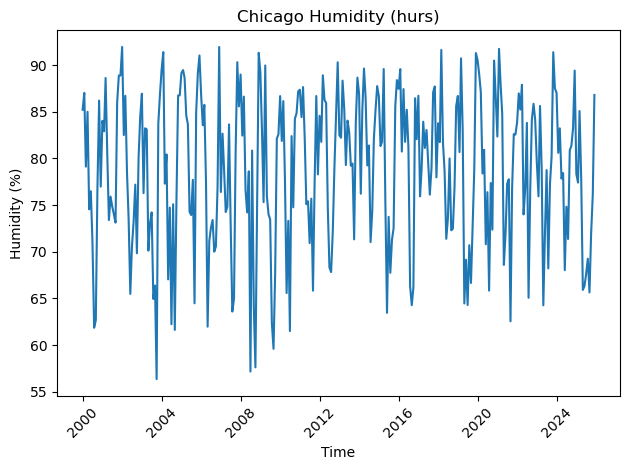

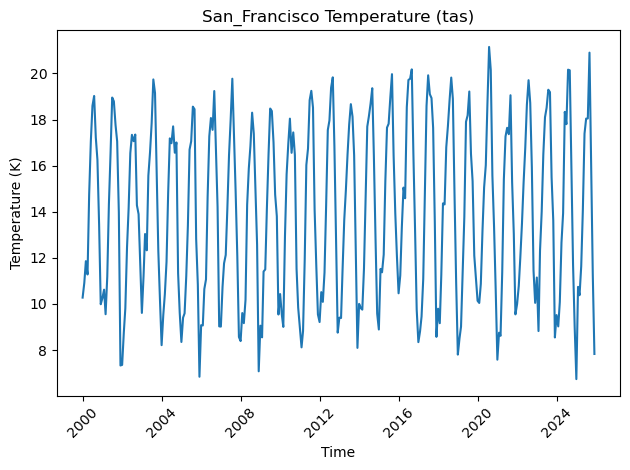

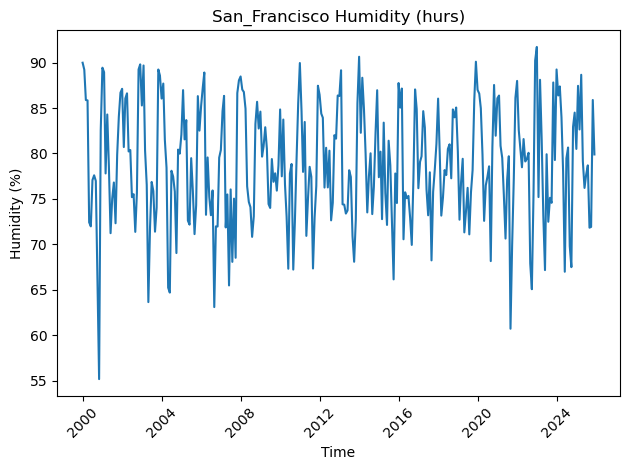

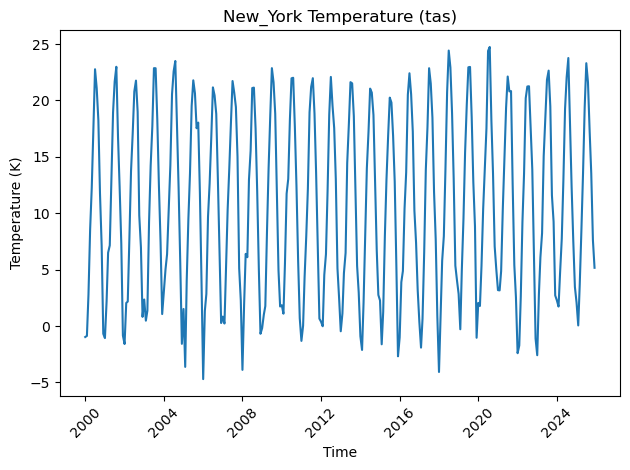

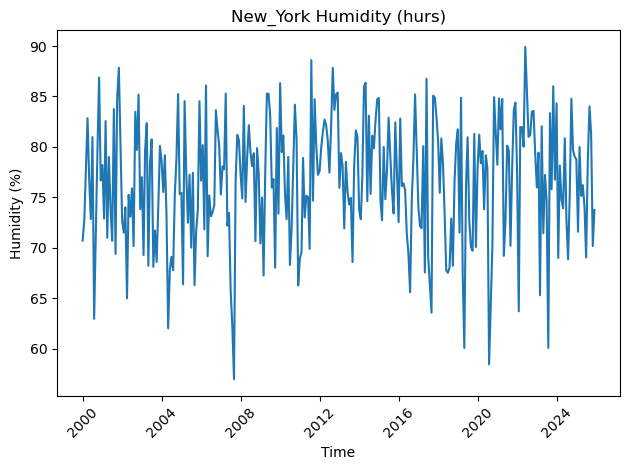

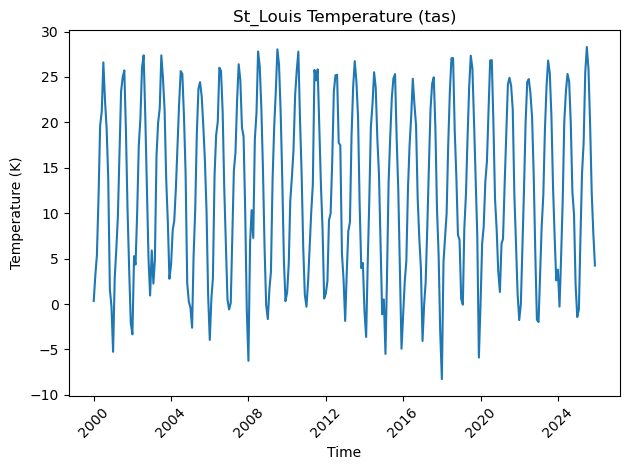

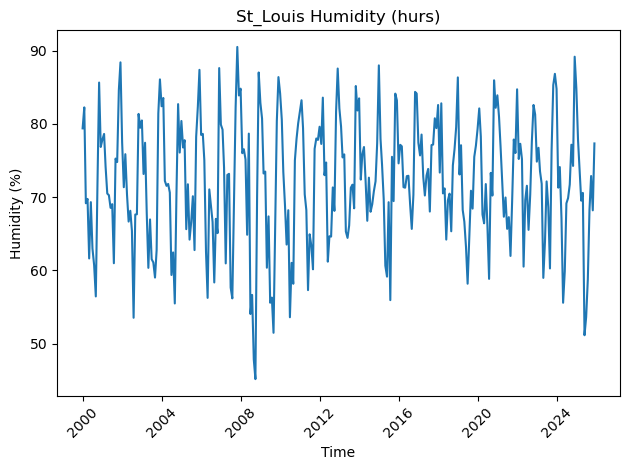

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder where your CSVs are saved
data_dir = "/home/hice1/jblack74/scratch/BHI/NEW_Cordex"

cities = [
    "Atlanta",
    "Los_Angeles",
    "Chicago",
    "San_Francisco",
    "New_York",
    "St_Louis"
]

for city in cities:
    file_path = os.path.join(data_dir, f"{city}_climate_new.csv")
    
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    
    # --- Temperature plot ---
    plt.figure()
    plt.plot(df['time'], df['tas'])
    plt.xlabel("Time")
    plt.ylabel("Temperature (K)")
    plt.title(f"{city} Temperature (tas)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # --- Humidity plot ---
    plt.figure()
    plt.plot(df['time'], df['hurs'])
    plt.xlabel("Time")
    plt.ylabel("Humidity (%)")
    plt.title(f"{city} Humidity (hurs)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

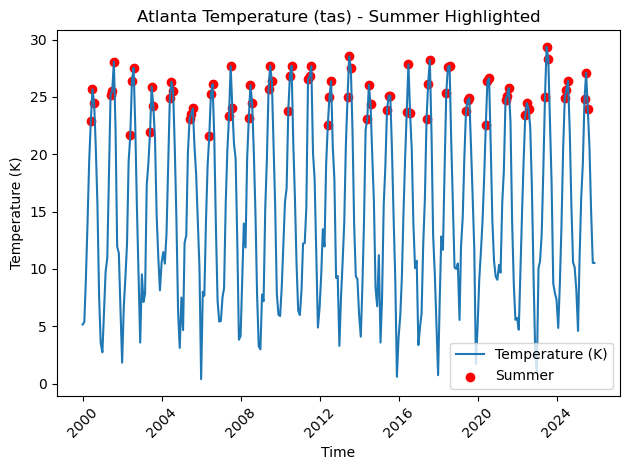

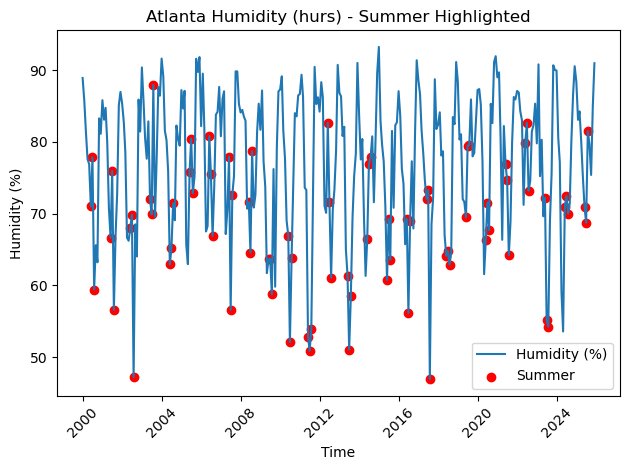

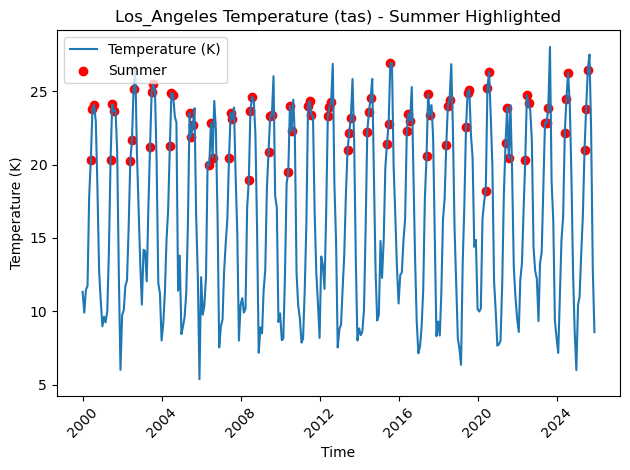

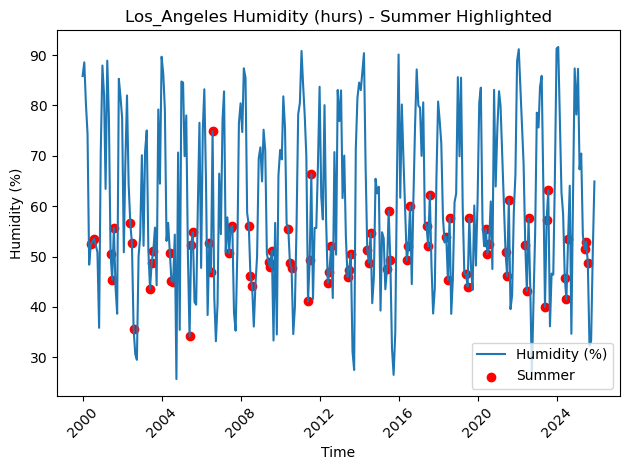

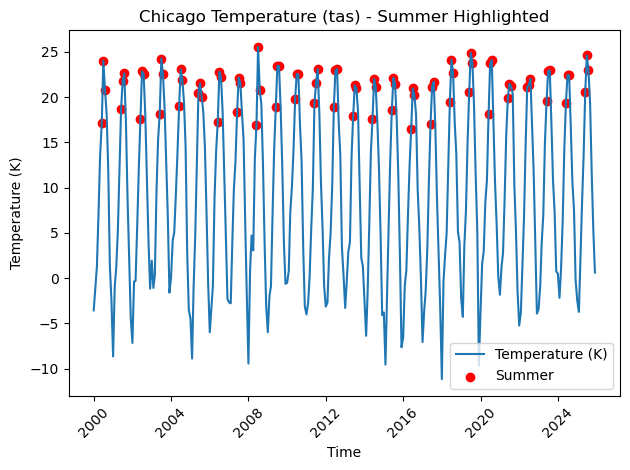

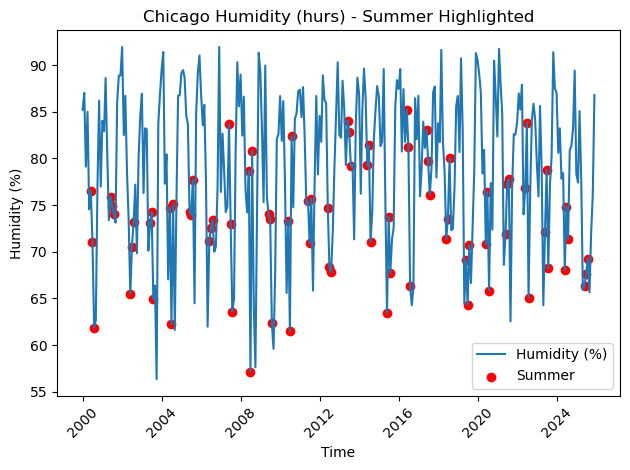

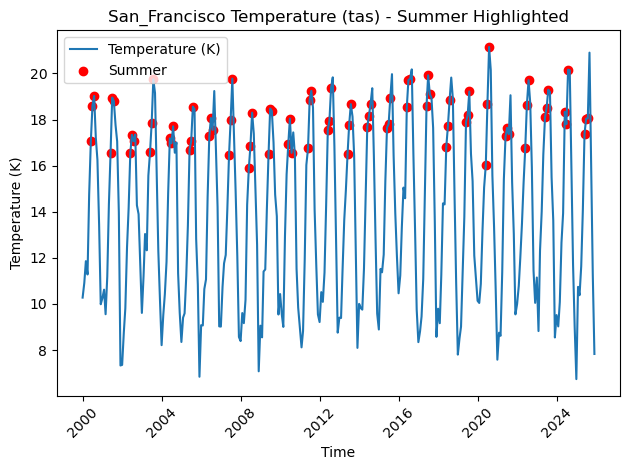

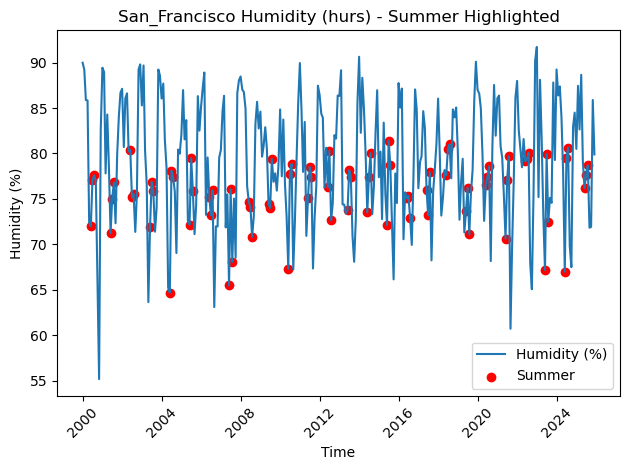

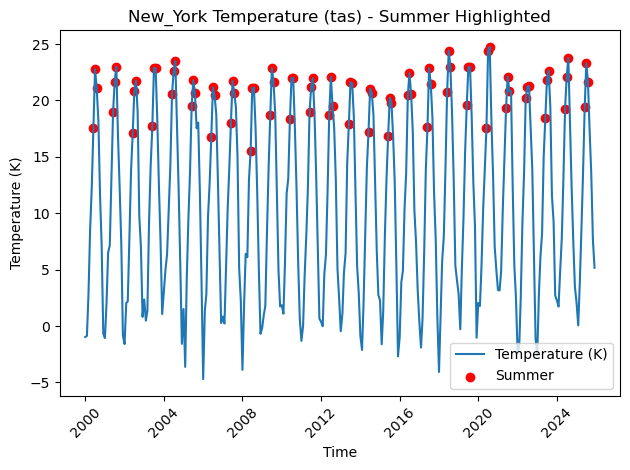

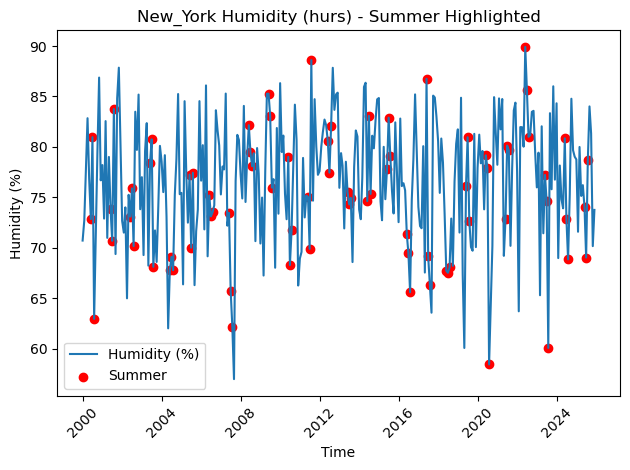

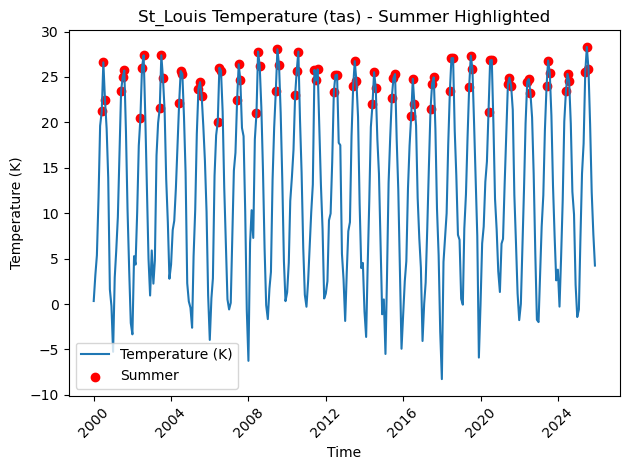

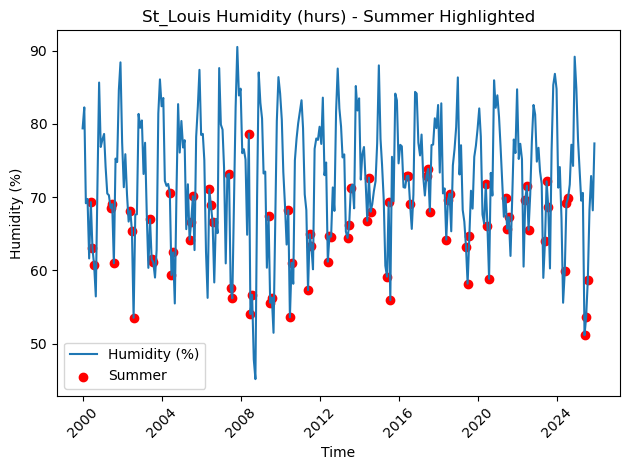

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder where your CSVs are saved
data_dir = "/home/hice1/jblack74/scratch/BHI/NEW_Cordex"

cities = [
    "Atlanta",
    "Los_Angeles",
    "Chicago",
    "San_Francisco",
    "New_York",
    "St_Louis"
]

for city in cities:
    file_path = os.path.join(data_dir, f"{city}_climate_new.csv")
    
    df = pd.read_csv(file_path)
    df['time'] = pd.to_datetime(df['time'])
    
    # Extract month
    df['month'] = df['time'].dt.month
    
    # Define summer months
    summer_mask = df['month'].isin([6, 7, 8])
    
    # --- Temperature plot ---
    plt.figure()
    
    # Base line
    plt.plot(df['time'], df['tas'], label='Temperature (K)')
    
    # Highlight summer points
    plt.scatter(df['time'][summer_mask], df['tas'][summer_mask],
                color='red', label='Summer')
    
    plt.xlabel("Time")
    plt.ylabel("Temperature (K)")
    plt.title(f"{city} Temperature (tas) - Summer Highlighted")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # --- Humidity plot ---
    plt.figure()
    
    # Base line
    plt.plot(df['time'], df['hurs'], label='Humidity (%)')
    
    # Highlight summer points
    plt.scatter(df['time'][summer_mask], df['hurs'][summer_mask],
                color='red', label='Summer')
    
    plt.xlabel("Time")
    plt.ylabel("Humidity (%)")
    plt.title(f"{city} Humidity (hurs) - Summer Highlighted")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()